# 03b · Weak SINDy in 10 minutes

**Claim.** Weak (integral) SINDy recovers the governing ODE at noise levels where the canonical
**finite-difference SINDy collapses** — because it never differentiates noisy data.

We show this on the chaotic **Lorenz** system.

In [2]:
# --- install kept INACTIVE; uncomment once to set up the environment ---
# !pip install -r ../requirements.txt
import os, sys, warnings
warnings.filterwarnings("ignore")

def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path:
                sys.path.insert(0, cand)
            return
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()

import numpy as np
import matplotlib.pyplot as plt
from sparse_demos import systems, libraries, solvers, metrics, plotting, weak
%matplotlib inline
np.set_printoptions(suppress=True, precision=3)

## 1 · The problem

SINDy fits a sparse $\Xi$ in $\dot X = \Theta(X)\,\Xi$, so it needs the derivative $\dot X$.
Estimating it from noisy samples is the weak link.

## 2 · The weak-form fix (one idea)

Multiply $\dot x_d=\sum_j \Xi_{jd}f_j(x)$ by a smooth, compactly supported **test function**
$\phi_k$ and integrate by parts:

$$\int \phi_k\,\dot x_d\,dt = -\int \dot\phi_k\,x_d\,dt \quad(\phi_k=0\text{ at the ends}).$$

The derivative now lands on the **known, analytic** $\dot\phi_k$ — never on the noisy data. With
$K$ test functions this is a linear system per state, $G\,\xi_d=b_d$, where
$G=\Phi\,\Theta(Y)$ and $b=-\dot\Phi\,Y$, solved by the same sparse regression (STLS) as vanilla
SINDy. We use bump test functions $\phi=(1-\tau^2)^p$, $\tau=(t-c)/r$.

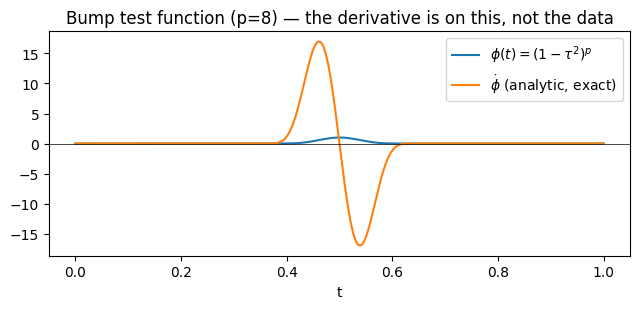

In [3]:
# one test function and its analytic derivative
tt = np.linspace(0, 1, 500)
p = 8
phi, phidot = weak.bump_test_function(tt, center=0.5, radius=0.15, p=p)
# phi, phidot = weak.bump_test_function(tt, center=0.5, radius=0.15, p=4)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(tt, phi, label=r"$\phi(t)=(1-\tau^2)^p$")
ax.plot(tt, phidot, label=r"$\dot\phi$ (analytic, exact)")
ax.axhline(0, color="k", lw=0.5); ax.set_xlabel("t"); ax.legend()
ax.set_title("Bump test function (p={}) — the derivative is on this, not the data".format(p))
plt.tight_layout(); plt.show()

## 3 · Setup

 Lorenz, degree-2 polynomial library, signal-relative noise $\sigma_d=\text{ratio}\cdot
\text{RMS}(x_d)$, and the **same** sparse-regression threshold for every method.

In [3]:
DT, T_END, DEGREE, THRESHOLD = 0.002, 10.0, 2, 0.5
t, X_clean = systems.simulate("lorenz", t_span=(0, T_END), dt=DT)
_, names = libraries.polynomial_library(X_clean, degree=DEGREE)
TARGETS = ["x'", "y'", "z'"]

def make_true_Xi(names):
    Xi = np.zeros((len(names), 3)); idx = {n: i for i, n in enumerate(names)}
    Xi[idx["x0"], 0], Xi[idx["x1"], 0] = -10.0, 10.0
    Xi[idx["x0"], 1], Xi[idx["x1"], 1], Xi[idx["x0 x2"], 1] = 28.0, -1.0, -1.0
    Xi[idx["x0 x1"], 2], Xi[idx["x2"], 2] = 1.0, -8.0/3.0
    return Xi
true_Xi = make_true_Xi(names)

def fit_fd(Y):     return weak.vanilla_sindy(t, Y, degree=DEGREE, threshold=THRESHOLD, derivative="fd")[0]
def fit_smooth(Y): return weak.vanilla_sindy(t, Y, degree=DEGREE, threshold=THRESHOLD, derivative="savgol", smooth_states=True, window=71)[0]
def fit_weak(Y):   return weak.weak_sindy(t, Y, degree=DEGREE, threshold=THRESHOLD, K=200, p=8, support_fraction=0.04)[0]
def correct(Xi):   return (metrics.support_match(true_Xi, Xi, 1e-6) == 1.0) and (metrics.coef_l2_error(true_Xi, Xi) <= 0.10)

In [4]:
# sanity: on CLEAN data the from-scratch weak form is essentially exact
print(f"weak SINDy, clean-data relative coefficient error = {metrics.coef_l2_error(true_Xi, fit_weak(X_clean)):.1e}")

weak SINDy, clean-data relative coefficient error = 3.8e-10


## 4 · One xample at 4%

At 4% measurement noise, finite-difference SINDy returns the **wrong** model; weak SINDy
recovers the true equations.

In [5]:
Xn, sigma = systems.add_measurement_noise(X_clean, 0.04, seed=0)
print(f"noise ratio = 4%")
print("================ TRUE ================");        solvers.print_model(true_Xi, names, TARGETS)
print("\n========= SINDy (finite diff) =======");      solvers.print_model(fit_fd(Xn), names, TARGETS)
print("\n============ weak SINDy =============");       solvers.print_model(fit_weak(Xn), names, TARGETS)
print(f"\nfinite-diff correct? {correct(fit_fd(Xn))}    weak correct? {correct(fit_weak(Xn))}")

noise ratio = 4%
================ TRUE ================
x' = -10.000 x0 +10.000 x1
y' = +28.000 x0 -1.000 x1 -1.000 x0 x2
z' = -2.667 x2 +1.000 x0 x1

========= SINDy (finite diff) =======
x' = -9.831 x0 +9.857 x1
y' = +25.093 x0 -0.935 x0 x2
z' = -1.807 1 -2.596 x2 +0.997 x0 x1

============ weak SINDy =============
x' = -9.971 x0 +9.976 x1
y' = +27.899 x0 -0.992 x1 -0.996 x0 x2
z' = -2.671 x2 +1.002 x0 x1

finite-diff correct? False    weak correct? True


## 5 · One example can be lucky — so sweep the noise

For each noise level we run 30 **paired** trials (identical noise given to every method) and
measure the exact-recovery rate. We include a **smoothed** finite-difference SINDy too, so the
baseline is fair — not just raw differences.

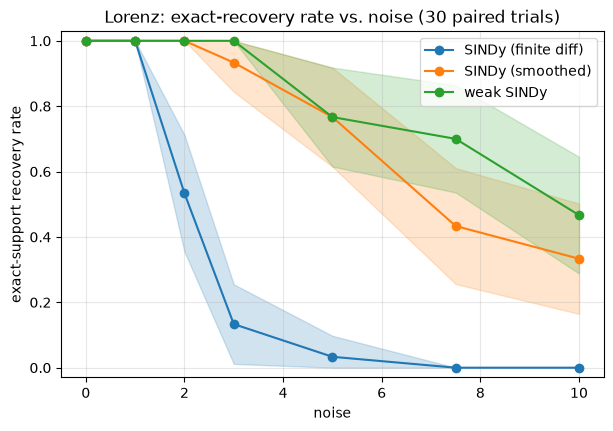

In [6]:
NOISE_GRID = [0.0, 1.0, 2.0, 3.0, 5.0, 7.5, 10.0]  # percent
N_TRIALS = 30
methods = {"SINDy (finite diff)": fit_fd, "SINDy (smoothed)": fit_smooth, "weak SINDy": fit_weak}
succ = {m: [] for m in methods}; ci = {m: [] for m in methods}
for pct in NOISE_GRID:
    hits = {m: 0 for m in methods}
    for k in range(N_TRIALS):
        Yn, _ = systems.add_measurement_noise(X_clean, pct / 100.0, seed=k)
        for m, fn in methods.items():
            hits[m] += correct(fn(Yn))
    for m in methods:
        # succ[m].append(hits[m] / N_TRIALS); ci[m].append(metrics.wilson_interval(hits[m], N_TRIALS))
        succ[m].append(hits[m] / N_TRIALS); ci[m].append(metrics.wald_interval(hits[m], N_TRIALS))


plotting.plot_success_vs_noise(NOISE_GRID, succ, ci,
    title=f"Lorenz: exact-recovery rate vs. noise ({N_TRIALS} paired trials)")
plt.show()

## Polynomial degree 4

In [7]:
DT, T_END, DEGREE, THRESHOLD = 0.002, 10.0, 4, 0.8
t, X_clean = systems.simulate("lorenz", t_span=(0, T_END), dt=DT)
_, names = libraries.polynomial_library(X_clean, degree=DEGREE)
TARGETS = ["x'", "y'", "z'"]

def make_true_Xi(names):
    Xi = np.zeros((len(names), 3)); idx = {n: i for i, n in enumerate(names)}
    Xi[idx["x0"], 0], Xi[idx["x1"], 0] = -10.0, 10.0
    Xi[idx["x0"], 1], Xi[idx["x1"], 1], Xi[idx["x0 x2"], 1] = 28.0, -1.0, -1.0
    Xi[idx["x0 x1"], 2], Xi[idx["x2"], 2] = 1.0, -8.0/3.0
    return Xi
true_Xi = make_true_Xi(names)

def fit_fd(Y):     return weak.vanilla_sindy(t, Y, degree=DEGREE, threshold=THRESHOLD, derivative="fd")[0]
def fit_smooth(Y): return weak.vanilla_sindy(t, Y, degree=DEGREE, threshold=THRESHOLD, derivative="savgol", smooth_states=True, window=71)[0]
def fit_weak(Y):   return weak.weak_sindy(t, Y, degree=DEGREE, threshold=THRESHOLD, K=200, p=8, support_fraction=0.04)[0]
def correct(Xi):   return (metrics.support_match(true_Xi, Xi, 1e-6) == 1.0) and (metrics.coef_l2_error(true_Xi, Xi) <= 0.10)

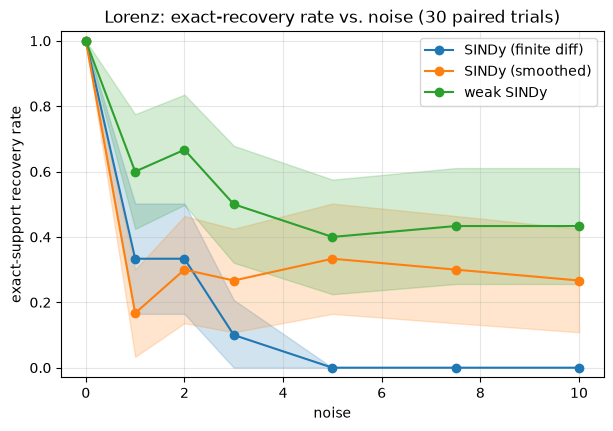

In [8]:
NOISE_GRID = [0.0, 1.0, 2.0, 3.0, 5.0, 7.5, 10.0]  # percent
N_TRIALS = 30
methods = {"SINDy (finite diff)": fit_fd, "SINDy (smoothed)": fit_smooth, "weak SINDy": fit_weak}
succ = {m: [] for m in methods}; ci = {m: [] for m in methods}
for pct in NOISE_GRID:
    hits = {m: 0 for m in methods}
    for k in range(N_TRIALS):
        Yn, _ = systems.add_measurement_noise(X_clean, pct / 100.0, seed=k)
        for m, fn in methods.items():
            hits[m] += correct(fn(Yn))
    for m in methods:
        # succ[m].append(hits[m] / N_TRIALS); ci[m].append(metrics.wilson_interval(hits[m], N_TRIALS))
        succ[m].append(hits[m] / N_TRIALS); ci[m].append(metrics.wald_interval(hits[m], N_TRIALS))


plotting.plot_success_vs_noise(NOISE_GRID, succ, ci,
    title=f"Lorenz: exact-recovery rate vs. noise ({N_TRIALS} paired trials)")
plt.show()

## 6 · Takeaway

* **Weak SINDy is far more noise-robust than finite-difference SINDy** — it moves the derivative
  onto a smooth, analytic test function and averages noise away by integration.
* **Smoothing the baseline helps but does not close the gap here** — and weak SINDy needs no
  smoothing-window choice.
* **Caveats:** a heavily *tuned* conventional pipeline can narrow the gap (it needs the
  answer you are looking for), the library is still evaluated on
  noisy states, so at large enough noise every method fails.
